
**✅ CIA 2: Customer Segmentation using Boltzmann Machine (RBM)**

👤 Name: Piyushkumar Ghate


🟦 🔹 Introduction

Customer segmentation is a technique used to group customers based on their purchasing behavior. In this assignment, we use a Boltzmann Machine (Restricted Boltzmann Machine - RBM) to learn hidden patterns in customer transactions.

The dataset contains retail transaction data including customer IDs, product IDs, and purchase quantities. By transforming the data into a binary format, we can model whether a product was purchased or not.

🟦 🔹 Objective
Load and clean the dataset
Preprocess and transform data into binary format
Train a Boltzmann Machine (RBM)
Identify hidden customer segments

1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import BernoulliRBM
from sklearn.cluster import KMeans

3. Load Dataset

In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/online_retail_II.xlsx"

try:
    df = pd.read_excel(file_path)
except:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')

print("Original Data Shape:", df.shape)
df.head()

Original Data Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


4. Data Cleaning

The dataset is cleaned by removing missing values and invalid transactions.

In [ ]:
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['Customer ID'] = df['Customer ID'].astype(str)

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (407664, 8)


5. Data Transformation

We convert the dataset into a Customer-Product matrix.

In [ ]:
customer_product = df.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print("Matrix Shape:", customer_product.shape)

Matrix Shape: (4312, 4017)


6. Binary Conversion

We convert quantities into binary values:

1 → Purchased
0 → Not Purchased

In [ ]:
customer_product_binary = (customer_product > 0).astype(int)

customer_product_binary.head()

StockCode,10002,10080,10109,10120,10125,10133,10134,10135,10138,11001,...,ADJUST2,BANK CHARGES,C2,D,M,PADS,POST,SP1002,TEST001,TEST002
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
12351.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


7. Train-Test Split

In [ ]:
X = customer_product_binary.values

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

8. Train RBM Model

RBM learns hidden patterns in customer behavior.

In [ ]:
rbm = BernoulliRBM(
    n_components=50,
    learning_rate=0.01,
    batch_size=10,
    n_iter=20,
    random_state=42,
    verbose=True
)

rbm.fit(X_train)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -990.86, time = 1.20s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -398.17, time = 1.35s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -356.63, time = 1.40s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -295.30, time = 1.36s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -280.97, time = 3.55s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -280.09, time = 1.36s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -278.46, time = 1.37s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -274.94, time = 1.40s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -271.45, time = 1.40s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -263.79, time = 1.33s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -261.51, time = 1.35s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -256.28, time = 1.33s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -255.20, time = 3.52s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -251.53, time = 1.30s
[BernoulliRBM] 

BernoulliRBM(learning_rate=0.01, n_components=50, n_iter=20, random_state=42,
             verbose=True)

9. Customer Segmentation

In [ ]:
train_transformed = rbm.transform(X_train)

print("Transformed Shape:", train_transformed.shape)

Transformed Shape: (3449, 50)


10. Visualization

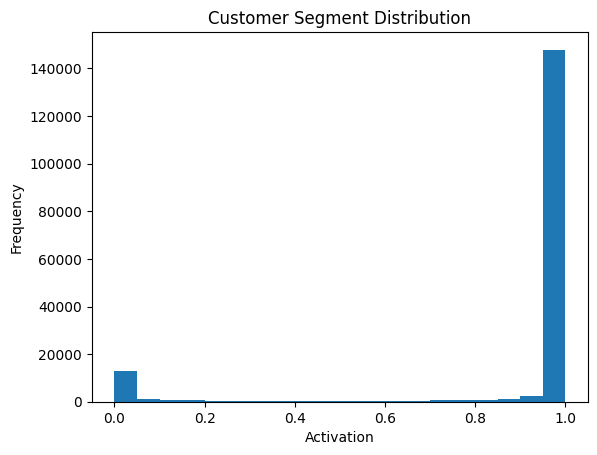

In [ ]:
plt.figure()
plt.hist(train_transformed.flatten(), bins=20)
plt.title("Customer Segment Distribution")
plt.xlabel("Activation")
plt.ylabel("Frequency")
plt.show()

11. Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(train_transformed)

print("Cluster Labels:", clusters[:10])

Cluster Labels: [1 0 1 3 1 1 3 1 1 1]


Conclusion

The RBM model successfully learned hidden representations of customer purchasing behavior. These representations can be used for customer segmentation, recommendation systems, and targeted marketing.